In [1]:
import pddl, time
from pddl_planner.planner.planner import FOLRegressionPlanner
from IPython.utils import io
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
def plan_run(domain_path, problem_path, max_depth, configs=(True, True, True, True, True)):
    pddl_domain = pddl.parse_domain(domain_path)
    pddl_problem = pddl.parse_problem(problem_path)
    planner = FOLRegressionPlanner(pddl_domain, pddl_problem, max_depth)
    start_time = time.perf_counter()
    plan = planner.regress_plan(*configs)
    end_time = time.perf_counter()
    time_taken = end_time - start_time
    return plan, time_taken

In [3]:
def horizon_test(domain_path, problem_path, title=""):
    depths = range(1, 8)
    times = []
    plans = []
    for depth in depths:
        plan, time_taken = plan_run(domain_path, problem_path, depth)
        times.append(time_taken)
        print(f"Depth: {depth}, Time: {time_taken}")
        plans.append(plan)
        print(plan)
        print("=====================================")

    plt.figure(figsize=(8, 6))
    plt.bar(depths, times)
    plt.xlabel("Max Horizon")
    plt.ylabel("Time (seconds)")
    plt.title(f"Planner Execution Times vs. Max Horizon{title}")
    plt.show()

    # plot total number of predicates in each depth
    total_predicates = [sum([subgoal[0].get_num_preds() for subgoal in plan]) for plan in plans]

    plt.figure(figsize=(8, 6))
    plt.bar(depths, total_predicates)
    plt.xlabel("Max Horizon")
    plt.ylabel("Total Formula Length")
    plt.title(f"Total Formula Length vs. Max Horizon{title}")
    ax = plt.gca()
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    plt.show()

Depth: 1, Time: 0.004427708001458086
[(((at(p0, toronto))), [], {}), (((?V81 == p0 ∧ ?V83 == toronto ∧ at(?V81, ?V82))), [Action('DRIVE-TRUCK'([?V81, ?V82, ?V83]))], {}), (((?V87 == p0 ∧ ?V89 == toronto ∧ at(?V88, ?V89) ∧ in(?V87, ?V88))), [Action('UNLOAD-TRUCK'([?V87, ?V88, ?V89]))], {})]
Depth: 2, Time: 0.02741045800212305
[(((at(p0, toronto))), [], {}), (((?V171 == p0 ∧ ?V173 == toronto ∧ at(?V171, ?V172))), [Action('DRIVE-TRUCK'([?V171, ?V172, ?V173]))], {}), (((?V177 == p0 ∧ ?V179 == toronto ∧ at(?V178, ?V179) ∧ in(?V177, ?V178))), [Action('UNLOAD-TRUCK'([?V177, ?V178, ?V179]))], {}), (((?V171 == p0 ∧ ?V173 == toronto ∧ at(?V187, ?V172) ∧ in(?V171, ?V187))), [Action('DRIVE-TRUCK'([?V171, ?V172, ?V173])), Action('UNLOAD-TRUCK'([?V186, ?V187, ?V188]))], {?V186: ?V171, ?V188: ?V172}), (((?V177 != ?V178 ∧ ?V177 == p0 ∧ ?V179 == toronto ∧ at(?V177, ?V194) ∧ at(?V178, ?V179) ∧ at(?V178, ?V194))), [Action('UNLOAD-TRUCK'([?V177, ?V178, ?V179])), Action('LOAD-TRUCK'([?V192, ?V193, ?V194]))

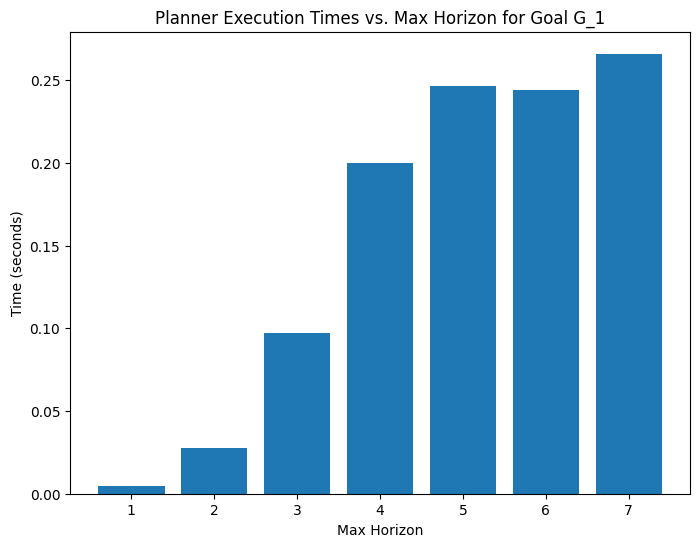

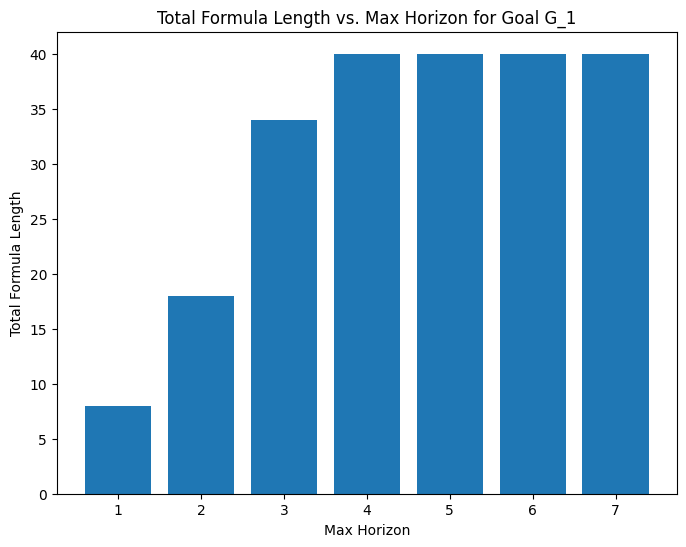

In [4]:
domain_path = '../../files/logistic_2.pddl'
problem_path = '../../files/logistic_problem1.pddl'
horizon_test(domain_path, problem_path, title=" for Goal G_1")

Depth: 1, Time: 0.02320595800119918
[(((at(p1, ottawa) ∧ at(p0, toronto))), [], {}), (((?V9072 == p0 ∧ ?V9072 == p1 ∧ ?V9074 == ottawa ∧ ?V9074 == toronto ∧ at(?V9073, ?V9074) ∧ in(?V9072, ?V9073))), [Action('UNLOAD-TRUCK'([?V9072, ?V9073, ?V9074]))], {}), (((?V9078 != p0 ∧ ?V9078 == p1 ∧ at(p0, toronto) ∧ ?V9080 == ottawa ∧ at(?V9078, ?V9079)) ∨ (?V9078 != p1 ∧ ?V9078 == p0 ∧ at(p1, ottawa) ∧ ?V9080 == toronto ∧ at(?V9078, ?V9079)) ∨ (?V9078 == p0 ∧ ?V9078 == p1 ∧ ?V9080 == ottawa ∧ ?V9080 == toronto ∧ at(?V9078, ?V9079))), [Action('DRIVE-TRUCK'([?V9078, ?V9079, ?V9080]))], {})]
Depth: 2, Time: 0.14681787500012433
[(((at(p1, ottawa) ∧ at(p0, toronto))), [], {}), (((?V9162 == p0 ∧ ?V9162 == p1 ∧ ?V9164 == ottawa ∧ ?V9164 == toronto ∧ at(?V9163, ?V9164) ∧ in(?V9162, ?V9163))), [Action('UNLOAD-TRUCK'([?V9162, ?V9163, ?V9164]))], {}), (((?V9168 != p0 ∧ ?V9168 == p1 ∧ at(p0, toronto) ∧ ?V9170 == ottawa ∧ at(?V9168, ?V9169)) ∨ (?V9168 != p1 ∧ ?V9168 == p0 ∧ at(p1, ottawa) ∧ ?V9170 == toront

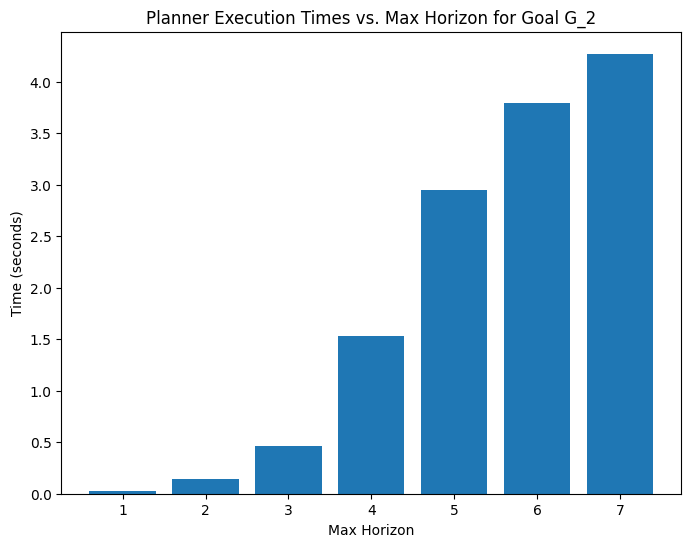

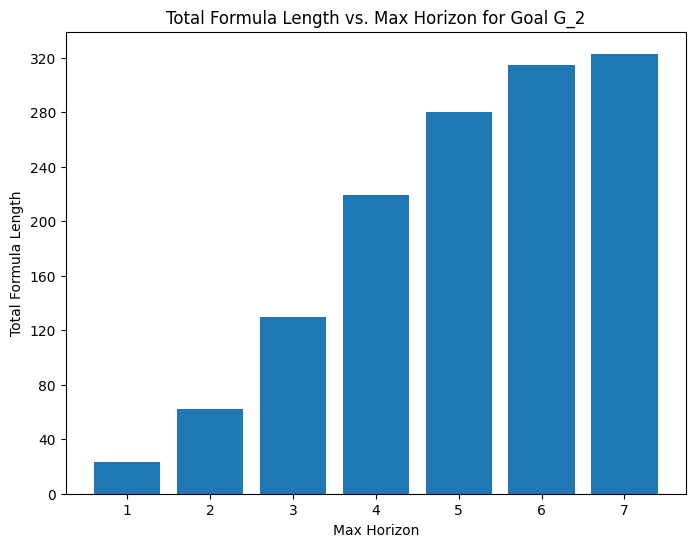

In [20]:
domain_path = '../../files/logistic_2.pddl'
problem_path = '../../files/logistic_problem2.pddl'
horizon_test(domain_path, problem_path, title=" for Goal G_2")

In [30]:
def action_test(problem_path, depth):
    num_action = range(1, 8)
    domain_paths = [f"../../files/logistic_action_{i}.pddl" for i in num_action]
    times = []
    plans = []
    for domain_path in domain_paths:
        plan, time_taken = plan_run(domain_path, problem_path, depth)
        times.append(time_taken)
        print(f"Domain: {domain_path}, Time: {time_taken}")
        plans.append(plan)
        print(plan)
        print("=====================================")

    plt.figure(figsize=(8, 6))
    plt.bar(num_action, times)
    plt.xlabel("Number of Actions")
    plt.ylabel("Time (seconds)")
    plt.title("Planner Execution Times vs. Number of Actions")
    plt.show()

    # plot total number of predicates in each depth
    total_predicates = [sum([subgoal[0].get_num_preds() for subgoal in plan]) for plan in plans]

    plt.figure(figsize=(8, 6))
    plt.bar(num_action, total_predicates)
    plt.xlabel("Number of Actions")
    plt.ylabel("Total Formula Length")
    plt.title("Total Formula Length vs. Number of Actions")
    ax = plt.gca()
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    plt.show()

Domain: ../../files/logistic_action_1.pddl, Time: 0.3277175839903066
[(((at(p0, l20))), [], {}), (((?V124284 == p0 ∧ ?V124286 == l20 ∧ at(?V124285, ?V124286) ∧ in(?V124284, ?V124285))), [Action('UNLOAD-TRUCK1'([?V124284, ?V124285, ?V124286]))], {}), (((?V124287 == p0 ∧ ?V124289 == l20 ∧ at(?V124287, ?V124288))), [Action('DRIVE-TRUCK1'([?V124287, ?V124288, ?V124289]))], {}), (((?V124284 != ?V124285 ∧ ?V124284 == p0 ∧ ?V124286 == l20 ∧ at(?V124284, ?V124292) ∧ at(?V124285, ?V124286) ∧ at(?V124285, ?V124292))), [Action('UNLOAD-TRUCK1'([?V124284, ?V124285, ?V124286])), Action('LOAD-TRUCK1'([?V124290, ?V124291, ?V124292]))], {?V124290: ?V124284, ?V124291: ?V124285}), (((?V124284 == p0 ∧ ?V124286 == l20 ∧ at(?V124285, ?V124297) ∧ in(?V124284, ?V124285))), [Action('UNLOAD-TRUCK1'([?V124284, ?V124285, ?V124286])), Action('DRIVE-TRUCK1'([?V124296, ?V124297, ?V124298]))], {?V124296: ?V124285, ?V124298: ?V124286}), (((?V124287 == p0 ∧ ?V124289 == l20 ∧ at(?V124303, ?V124288) ∧ in(?V124287, ?V1243

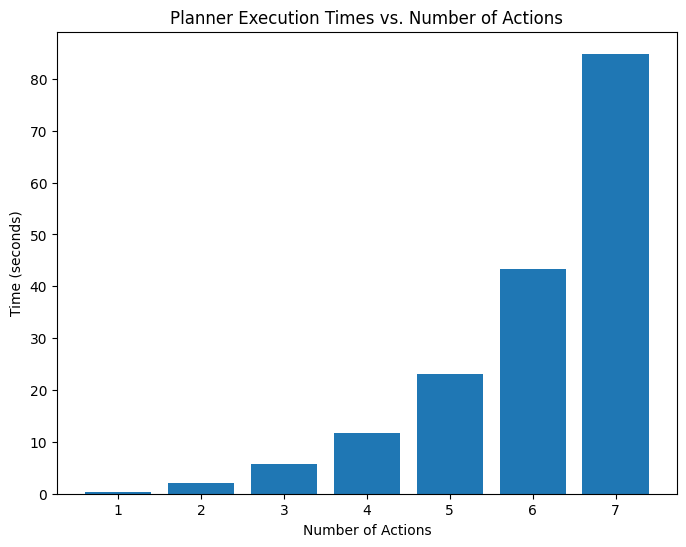

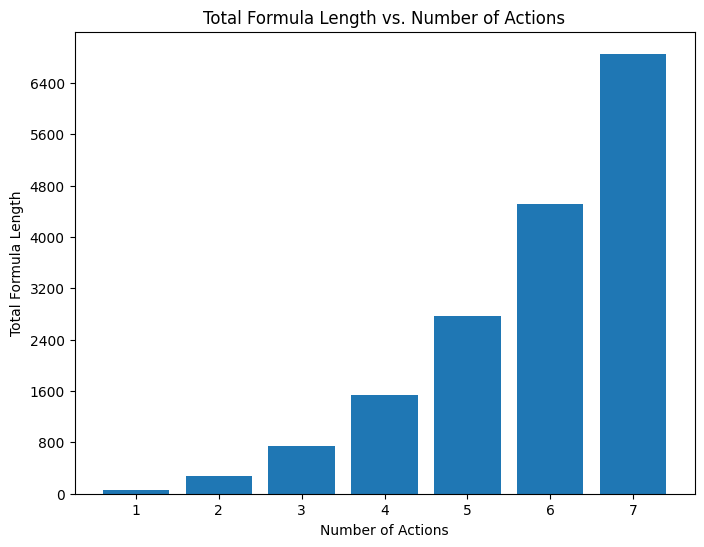

In [ ]:
depth = 3
problem_path = '../../files/logistic_problem1.pddl'
action_test(problem_path, depth)

In [9]:
def simplification_test(domain_path, problem_path, depth=3, title=""):
    simplification_configs = {
    "All": [True, True, True, True, True],
    "No Equality Based Elimination": [False, True, True, True, True],
    "No Contradiction Evaluation": [True, False, True, True, True],
    "No Type-based Pruning": [True, True, False, True, True],
    "No DNF Subsumption": [True, True, True, False, True],
    "No Duplicate Detection": [True, True, True, True, False],
    }
    times = []
    plans = []
    lengths = []

    config_names = list(simplification_configs.keys())
    for config in config_names:
            plan, time_taken = plan_run(domain_path, problem_path, depth, simplification_configs[config])
            times.append(time_taken)
            length = sum([subgoal[0].get_num_preds() for subgoal in plan])
            lengths.append(length)
            print(f"Simplification: {config}, Time: {time_taken}, Length: {length}")
            plans.append(plan)
            print(plan)
            print("=====================================")


    # Plot execution times with rotated x labels
    plt.figure(figsize=(8, 6))
    plt.bar(config_names, times)
    plt.xlabel("Simplification Performed")
    plt.ylabel("Time (seconds)")
    plt.title(f"Planner Execution Times vs. Simplification Performed {title}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    # Plot total number of predicates
    total_predicates = [sum([subgoal[0].get_num_preds() for subgoal in plan]) for plan in plans]
    plt.figure(figsize=(8, 6))
    plt.bar(config_names, total_predicates)
    plt.xlabel("Simplification Performed")
    plt.ylabel("Total Formula Length")
    plt.title(f"Total Formula Length vs. Simplification Performed {title}")
    plt.xticks(rotation=45, ha="right")
    ax = plt.gca()
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    plt.tight_layout()
    plt.show()

Simplification: All, Time: 0.3557486670000003, Length: 40
[(((at(p0, toronto))), [], {}), (((?V3789 == p0 ∧ ?V3791 == toronto ∧ at(?V3790, ?V3791) ∧ in(?V3789, ?V3790))), [Action('UNLOAD-TRUCK'([?V3789, ?V3790, ?V3791]))], {}), (((?V3795 == p0 ∧ ?V3797 == toronto ∧ at(?V3795, ?V3796))), [Action('DRIVE-TRUCK'([?V3795, ?V3796, ?V3797]))], {}), (((?V3789 == p0 ∧ ?V3789 != ?V3790 ∧ ?V3791 == toronto ∧ at(?V3789, ?V3803) ∧ at(?V3790, ?V3791) ∧ at(?V3790, ?V3803))), [Action('UNLOAD-TRUCK'([?V3789, ?V3790, ?V3791])), Action('LOAD-TRUCK'([?V3801, ?V3802, ?V3803]))], {?V3801: ?V3789, ?V3802: ?V3790}), (((?V3789 == p0 ∧ ?V3791 == toronto ∧ at(?V3790, ?V3805) ∧ in(?V3789, ?V3790))), [Action('UNLOAD-TRUCK'([?V3789, ?V3790, ?V3791])), Action('DRIVE-TRUCK'([?V3804, ?V3805, ?V3806]))], {?V3804: ?V3790, ?V3806: ?V3791}), (((?V3789 == p0 ∧ ?V3789 != ?V3790 ∧ ?V3791 == toronto ∧ at(?V3789, ?V3823) ∧ at(?V3790, ?V3791) ∧ at(?V3790, ?V3803)) ∨ (?V3789 == p0 ∧ ?V3789 != ?V3790 ∧ ?V3791 == toronto ∧ at(?V37

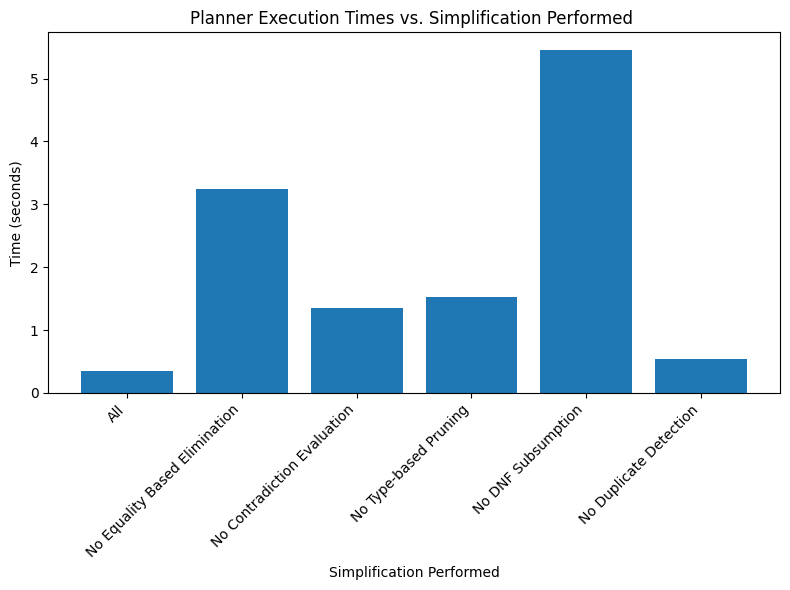

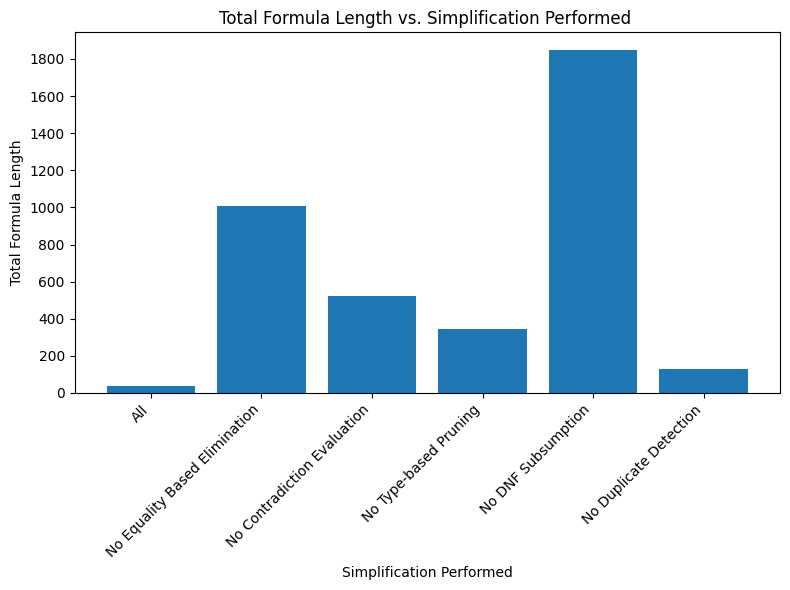

In [10]:
domain_path = '../../files/logistic_2.pddl'
problem_path = '../../files/logistic_problem1.pddl'
simplification_test(domain_path, problem_path, depth=4)

Simplification: All, Time: 0.38031445800000085, Length: 40
[(((at(p0, toronto))), [], {}), (((?V5382 == p0 ∧ ?V5384 == toronto ∧ at(?V5383, ?V5384) ∧ in(?V5382, ?V5383))), [Action('UNLOAD-TRUCK'([?V5382, ?V5383, ?V5384]))], {}), (((?V5388 == p0 ∧ ?V5390 == toronto ∧ at(?V5388, ?V5389))), [Action('DRIVE-TRUCK'([?V5388, ?V5389, ?V5390]))], {}), (((?V5382 == p0 ∧ ?V5382 != ?V5383 ∧ ?V5384 == toronto ∧ at(?V5382, ?V5396) ∧ at(?V5383, ?V5384) ∧ at(?V5383, ?V5396))), [Action('UNLOAD-TRUCK'([?V5382, ?V5383, ?V5384])), Action('LOAD-TRUCK'([?V5394, ?V5395, ?V5396]))], {?V5394: ?V5382, ?V5395: ?V5383}), (((?V5382 == p0 ∧ ?V5384 == toronto ∧ at(?V5383, ?V5398) ∧ in(?V5382, ?V5383))), [Action('UNLOAD-TRUCK'([?V5382, ?V5383, ?V5384])), Action('DRIVE-TRUCK'([?V5397, ?V5398, ?V5399]))], {?V5397: ?V5383, ?V5399: ?V5384}), (((?V5382 == p0 ∧ ?V5382 != ?V5383 ∧ ?V5384 == toronto ∧ at(?V5382, ?V5416) ∧ at(?V5383, ?V5384) ∧ at(?V5383, ?V5396)) ∨ (?V5382 == p0 ∧ ?V5382 != ?V5383 ∧ ?V5384 == toronto ∧ at(?V5

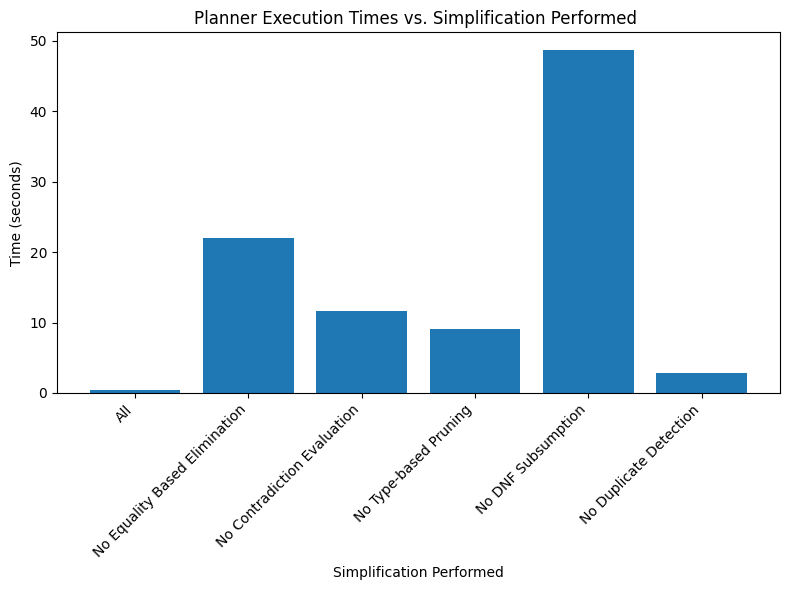

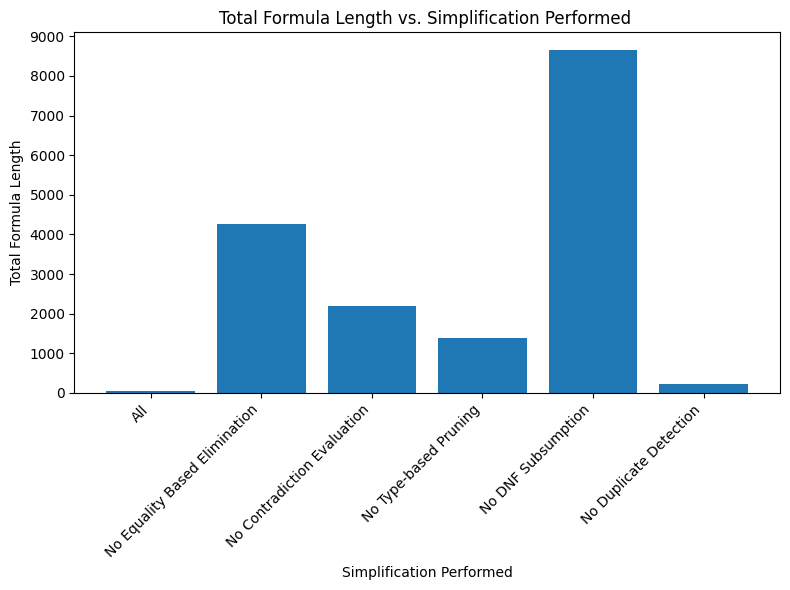

In [11]:
domain_path = '../../files/logistic_2.pddl'
problem_path = '../../files/logistic_problem1.pddl'
simplification_test(domain_path, problem_path, depth=5)